This project builds and compares three deep learning models to automatically classify rice leaf diseases from images — Bacterial Leaf Blight, Brown Spot, and Leaf Smut — using a dataset of 119 images. The goal is to identify which modeling approach (training from scratch vs. transfer learning) gives the most reliable results on a small agricultural image dataset.

### **Import Libraries**

In [ ]:
import os,random,shutil,time,warnings
warnings.filterwarnings('ignore')

import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import math
import tensorflow as tf
from PIL import Image
from tqdm import tqdm
from tensorflow import keras
from tensorflow.keras import layers,models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16, MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import(accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,classification_report)
from skimage.feature import hog
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg_preprocess
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess
from sklearn.model_selection import StratifiedKFold
from tensorflow.keras.regularizers import l2

### **Dataset Loading**

In [ ]:
zip_file_path = '/content/PRCP-1001-RiceLeaf.zip'
extract_dir = 'RiceLeaf'

if not os.path.exists(extract_dir):
    os.makedirs(extract_dir)

with zipfile.ZipFile(zip_file_path, 'r') as zf:
    zf.extractall(extract_dir)

Unzipped the Rice Leaf dataset (PRCP-1001-RiceLeaf.zip) containing images across 3 disease classes. A total of 119 images were found: 40 Bacterial Leaf Blight, 40 Brown Spot, and 39 Leaf Smut.

In [ ]:
for root, dirs, files in os.walk(extract_dir):
  for file in files:
    if file.endswith('.zip'):
      zip_file_path = os.path.join(root, file)
      destination_dir = root

      if not os.path.exists(destination_dir):
        os.makedirs(destination_dir)

      with zipfile.ZipFile(zip_file_path,'r') as zf:
        zf.extractall(destination_dir)

In [ ]:
SEED = 42
IMG_SIZE =(128,128)
BATCH_SIZE = 8
EPOCHS = 40

np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

def find_data_parent_dir(base):
    for root, dirs, files in os.walk(base):
        if 'Data' in dirs:
            data_path = os.path.join(root, 'Data')

            date_folders = [d for d in os.listdir(data_path) if os.path.isdir(os.path.join(data_path, d))]

            for date_folder in date_folders:
                full_date_path = os.path.join(data_path, date_folder)
                class_folders = [d for d in os.listdir(full_date_path) if os.path.isdir(os.path.join(full_date_path, d))]

                for class_folder in class_folders:
                    full_class_path = os.path.join(full_date_path, class_folder)
                    if os.path.isdir(full_class_path) and any(f.lower().endswith(('.jpg', '.jpeg', '.png')) for f in os.listdir(full_class_path)):
                        return data_path
    return base

DATA_DIR = find_data_parent_dir(extract_dir)

CLASSES = set()
for date_folder_name in os.listdir(DATA_DIR):
    date_folder_path = os.path.join(DATA_DIR, date_folder_name)

    if os.path.isdir(date_folder_path):
        for class_folder_name in os.listdir(date_folder_path):
            class_folder_path = os.path.join(date_folder_path, class_folder_name)

            if os.path.isdir(class_folder_path):
                if any(f.lower().endswith(('.jpg', '.jpeg', '.png')) for f in os.listdir(class_folder_path)):
                    CLASSES.add(class_folder_name)


CLASSES = sorted(list(CLASSES))

NUM_CLASSES = len(CLASSES)
CLASS_TO_IDX = {cls:idx for idx,cls in enumerate(CLASSES)}

print(f'DATA_DIR       : {DATA_DIR}')
print(f'Classes found  : {CLASSES};')
print(f'Num classes    : {NUM_CLASSES}')
print(f'Class Index   : {CLASS_TO_IDX}')

DATA_DIR       : RiceLeaf
Classes found  : ['Bacterial leaf blight', 'Brown spot', 'Leaf smut'];
Num classes    : 3
Class Index   : {'Bacterial leaf blight': 0, 'Brown spot': 1, 'Leaf smut': 2}


In [ ]:
DATA_DIR = os.path.join(DATA_DIR,'Data')

image_paths,labels= [],[]
for cls in CLASSES:
  cls_folder = os.path.join(DATA_DIR,cls)
  for img_file in os.listdir(cls_folder):
       if img_file.lower().endswith(('.jpg','.jpeg','.png')):
           image_paths.append(os.path.join(cls_folder, img_file))
           labels.append(CLASS_TO_IDX[cls])
print(f'Total images : {len(image_paths)}')
print('Distribution  :', {cls: labels.count(idx) for cls, idx in CLASS_TO_IDX.items()})

Total images : 119
Distribution  : {'Bacterial leaf blight': 40, 'Brown spot': 40, 'Leaf smut': 39}


### **Sample Visualization**

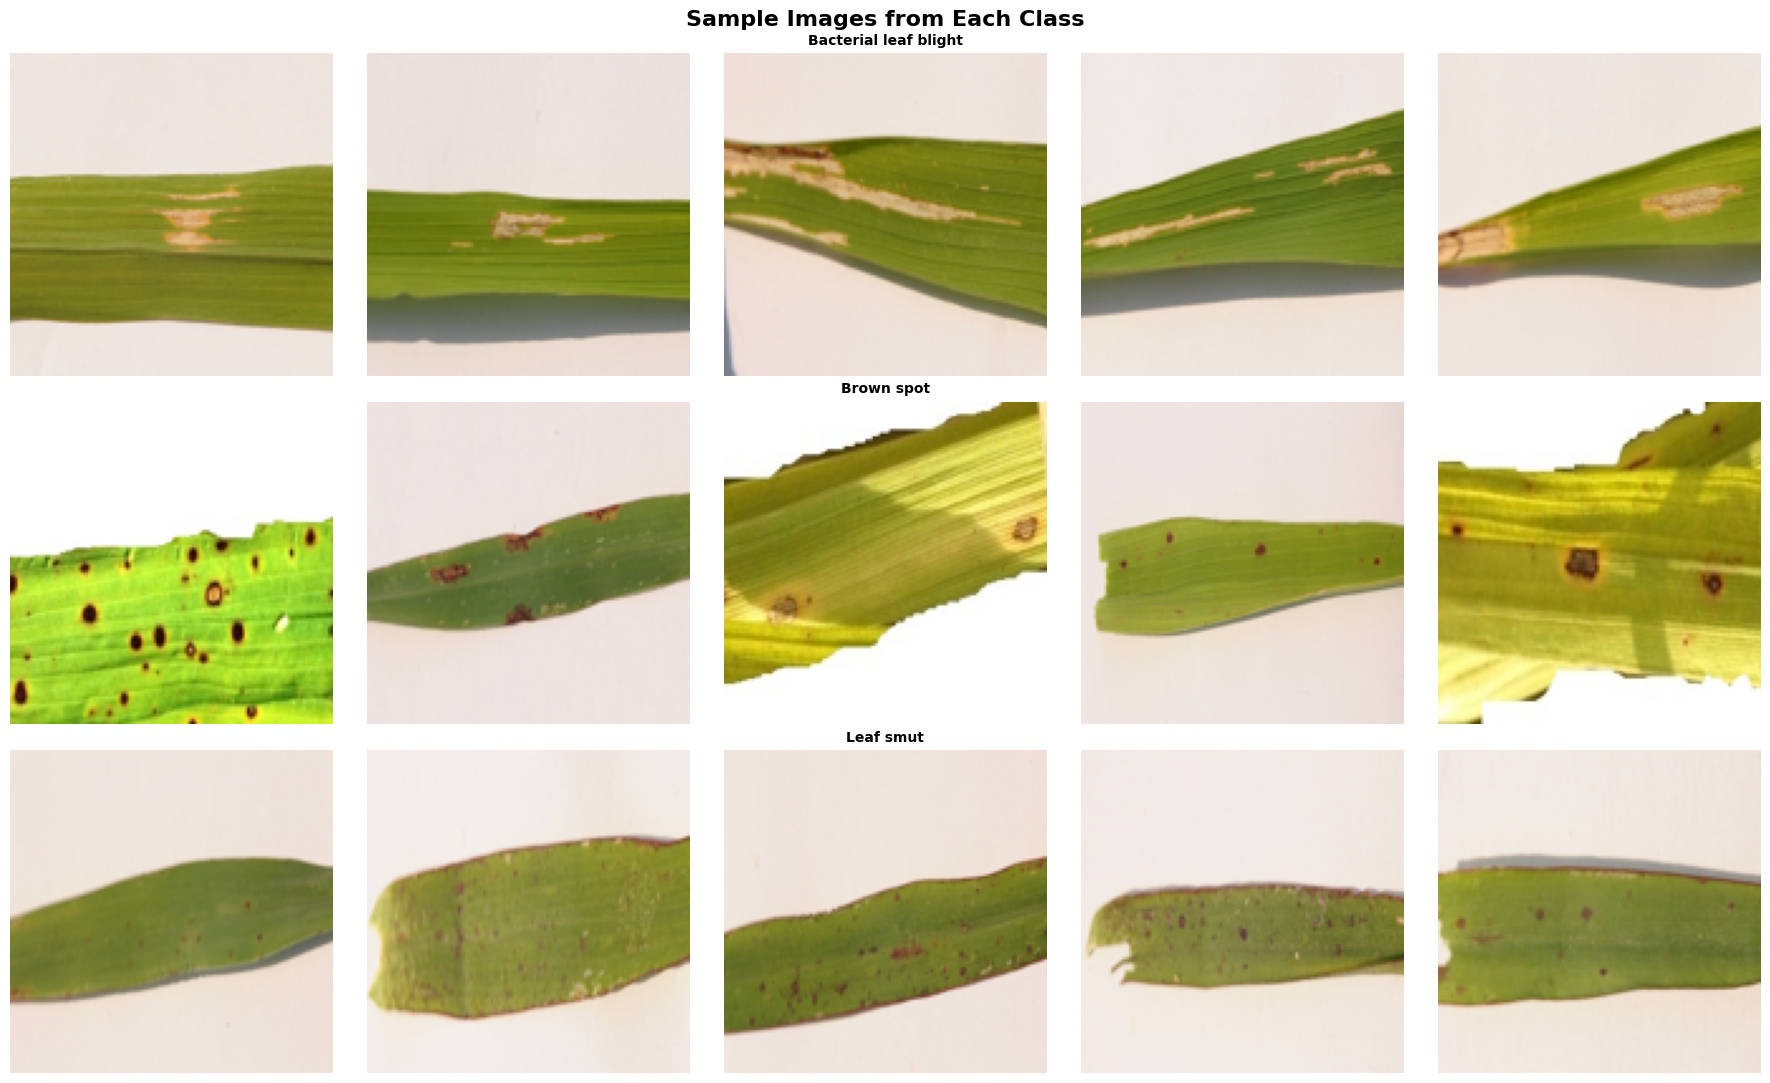

In [ ]:
fig,axes = plt.subplots(3,5, figsize=(18,11))
fig.suptitle('Sample Images from Each Class',fontsize=16, fontweight='bold')

for row, cls in enumerate (CLASSES):
  cls_folder = os.path.join(DATA_DIR,cls)
  imgs = [f for f in os.listdir(cls_folder) if f.lower().endswith(('.jpg','.jpeg','.png'))]
  samples = random.sample(imgs,min(5,len(imgs)))
  for col, img_name in  enumerate(samples):
    img = Image.open (os.path.join(cls_folder, img_name)).resize(IMG_SIZE)
    axes[row, col].imshow(img)
    axes[row, col].set_title(cls if col == 2 else'', fontsize=10, fontweight='bold')
    axes[row, col].axis('off')
plt.tight_layout()
plt.show()

Displayed sample images from each class to visually inspect the differences between the three disease types

### **Exploratory Data Analysis (EDA)**

In [ ]:
records = []
for path, label in zip(image_paths, labels):
    img = Image.open(path)
    records.append({
        'filepath' : path,
        'class'    : CLASSES[label],
        'label'    : label,
        'width'    : img.size[0],
        'height'   : img.size[1],
        'mode'     : img.mode,
    })
df = pd.DataFrame(records)
print(f'Shape:{df.shape}')
df.head(10)

Shape:(119, 6)


,filepath,class,label,width,height,mode
0,RiceLeaf/Data/Bacterial leaf blight/DSC_0376.JPG,Bacterial leaf blight,0,3081,897,RGB
1,RiceLeaf/Data/Bacterial leaf blight/DSC_0378.JPG,Bacterial leaf blight,0,3081,897,RGB
2,RiceLeaf/Data/Bacterial leaf blight/DSC_0384.JPG,Bacterial leaf blight,0,3081,897,RGB
3,RiceLeaf/Data/Bacterial leaf blight/DSC_0700.jpg,Bacterial leaf blight,0,3081,897,RGB
4,RiceLeaf/Data/Bacterial leaf blight/DSC_0383.JPG,Bacterial leaf blight,0,3081,897,RGB
5,RiceLeaf/Data/Bacterial leaf blight/DSC_0366.jpg,Bacterial leaf blight,0,3081,897,RGB
6,RiceLeaf/Data/Bacterial leaf blight/DSC_0380.JPG,Bacterial leaf blight,0,3081,897,RGB
7,RiceLeaf/Data/Bacterial leaf blight/DSC_0400.JPG,Bacterial leaf blight,0,3081,897,RGB
8,RiceLeaf/Data/Bacterial leaf blight/DSC_0398.JPG,Bacterial leaf blight,0,3081,897,RGB
9,RiceLeaf/Data/Bacterial leaf blight/DSC_0403.JPG,Bacterial leaf blight,0,3081,897,RGB


Built a DataFrame with image metadata (path, class, width, height, mode) and checked for missing values, duplicates, and class balance.

In [ ]:
print('=== dtypes & non-null counts ===')
df.info()
print('\n=== Missing vlaues ===')
print(df.isnull().sum())
print('\n=== Duplicates ===')
print('Duplicate paths:', df['filepath'].duplicated().sum())
print('\n=== Class distribution ===')
print(df['class'].value_counts())
print('\n=== Image dimension stats ===')
print(df[['width','height']].describe().round(1))

=== dtypes & non-null counts ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119 entries, 0 to 118
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   filepath  119 non-null    object
 1   class     119 non-null    object
 2   label     119 non-null    int64 
 3   width     119 non-null    int64 
 4   height    119 non-null    int64 
 5   mode      119 non-null    object
dtypes: int64(3), object(3)
memory usage: 5.7+ KB

=== Missing vlaues ===
filepath    0
class       0
label       0
width       0
height      0
mode        0
dtype: int64

=== Duplicates ===
Duplicate paths: 0

=== Class distribution ===
class
Bacterial leaf blight    40
Brown spot               40
Leaf smut                39
Name: count, dtype: int64

=== Image dimension stats ===
        width  height
count   119.0   119.0
mean   2383.6   707.7
std    1123.5   311.7
min     250.0    71.0
25%    1074.0   377.0
50%    3081.0   897.0
75%    3081.0   897.

In [ ]:
bright = {cls: [] for cls in CLASSES}
sharp = {cls: [] for cls in CLASSES}

if not df.empty:
    for index, row in df.iterrows():
        img_path = row['filepath']
        img_class = row['class']

        img = cv2.imread(img_path)
        if img is None:
            print(f"Warning: Could not load image at {img_path}. Skipping.")
            continue

        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        img_hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)
        brightness_val = np.mean(img_hsv[:, :, 2])

        gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
        sharpness_val = cv2.Laplacian(gray, cv2.CV_64F).var()

        bright[img_class].append(brightness_val)
        sharp[img_class].append(sharpness_val)

    print("Variables 'bright' and 'sharp' have been populated.")
    for cls in CLASSES:
        print(f"Class '{cls}' - Brightness samples: {bright[cls][:5]}")
        print(f"Class '{cls}' - Sharpness samples: {sharp[cls][:5]}")

else:
    print("DataFrame 'df' is empty. Cannot compute 'bright' and 'sharp'. Please ensure 'df' is populated with image data first.")

Variables 'bright' and 'sharp' have been populated.
Class 'Bacterial leaf blight' - Brightness samples: [np.float64(201.27753516445782), np.float64(186.64402528967958), np.float64(211.46572241055964), np.float64(221.47746699391422), np.float64(196.08499571401228)]
Class 'Bacterial leaf blight' - Sharpness samples: [np.float64(10.753297890587113), np.float64(53.357930727595885), np.float64(17.553046893431382), np.float64(97.19823551928629), np.float64(39.85856189363486)]
Class 'Brown spot' - Brightness samples: [np.float64(212.54604460683797), np.float64(198.36651566339066), np.float64(215.0945905050123), np.float64(209.97414956671426), np.float64(190.7489738522347)]
Class 'Brown spot' - Sharpness samples: [np.float64(6.9493178784266165), np.float64(881.1367078258755), np.float64(684.4682620600065), np.float64(287.4833937170566), np.float64(321.09738321746727)]
Class 'Leaf smut' - Brightness samples: [np.float64(204.75730924640794), np.float64(197.7382356059381), np.float64(197.79360137

Analyzed brightness and sharpness of images per class using HSV and Laplacian variance to understand image quality/consistency.

### **Data Preprocessing & Feature Engineering**

In [ ]:
def load_images(paths,lbls, size=(128,128)):
  X,y = [],[]
  for path, label in tqdm(zip(paths,lbls),total= len(paths), desc='Loading'):
      img = cv2.imread(path)
      img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
      img = cv2.resize(img, size)
      X.append(img)
      y.append(label)
  return np.array(X, dtype=np.float32), np.array(y)

x,y = load_images(image_paths, labels, IMG_SIZE)
print(f'X shape : {x.shape}  |  dtype : {x.dtype}')
if x.size > 0:
    print(f'y shape : {y.shape}  |  pixel range : [{x.min():.2f}, {x.max():.2f}]')
else:
    print(f'y shape : {y.shape}  |  pixel range : [N/A, N/A] (x is empty)')

Loading: 100%|██████████| 119/119 [00:01<00:00, 69.22it/s]

X shape : (119, 128, 128, 3)  |  dtype : float32
y shape : (119,)  |  pixel range : [0.00, 255.00]


Loaded and resized all images to 128x128 pixels, converting them into NumPy arrays for model input.

### **One-Hot Encoding & Train-Test Split**

In [ ]:
y_cat = to_categorical(y, num_classes=NUM_CLASSES)

X_trainval, X_test, y_trainval, y_test=train_test_split(x, y_cat, test_size=0.20, random_state=SEED, stratify=y)

X_train, X_val, y_train, y_val =train_test_split(X_trainval, y_trainval, test_size=0.15, random_state=SEED, stratify=np.argmax(y_trainval,axis=1))

y_test_int = np.argmax(y_test, axis=1)

print(f'Train :{X_train.shape[0]} images')
print(f'val   :{X_val.shape[0]}   images')
print(f'Test :{X_test.shape[0]}  images')

steps_per_epoch=max(1, math.ceil(X_train.shape[0]/BATCH_SIZE))
validation_steps=max(1,math.ceil(X_val.shape[0]/BATCH_SIZE))
test_steps=max(1,math.ceil(X_test.shape[0]/BATCH_SIZE))

Train :80 images
val   :15   images
Test :24  images


Converted class labels into one-hot encoded vectors and split data into Train (80), Validation (15), Test (24) sets using stratified sampling to preserve class balance.

### **Data Augmentation**

In [ ]:
AUG_KWARGS=dict(
    rotation_range=25,
    width_shift_range=0.12,
    height_shift_range=0.12,
    shear_range=0.10,
    zoom_range=0.15,
    horizontal_flip=True,
    vertical_flip=False,
    brightness_range=[0.85,1.15],
    fill_mode='nearest')

custom_train_datagen = ImageDataGenerator(rescale=1./255,**AUG_KWARGS)
custom_val_datagen  = ImageDataGenerator(rescale=1./255)

vgg_train_datagen = ImageDataGenerator(preprocessing_function=vgg_preprocess, **AUG_KWARGS)
vgg_val_datagen = ImageDataGenerator(preprocessing_function=vgg_preprocess)

mobilenet_train_datagen = ImageDataGenerator(preprocessing_function=mobilenet_preprocess,**AUG_KWARGS)
mobilenet_val_datagen = ImageDataGenerator(preprocessing_function=mobilenet_preprocess)

custom_train_gen = custom_train_datagen.flow(X_train,y_train,batch_size=BATCH_SIZE,seed=SEED)
custom_val_gen = custom_val_datagen.flow(X_val,y_val,batch_size=BATCH_SIZE,shuffle=False)

vgg_train_gen = vgg_train_datagen.flow(X_train,y_train,batch_size=BATCH_SIZE,seed=SEED)
vgg_val_gen = vgg_val_datagen.flow(X_val,y_val,batch_size=BATCH_SIZE,shuffle=False)

mobilenet_train_gen = mobilenet_train_datagen.flow(X_train,y_train,batch_size=BATCH_SIZE,seed=SEED)
mobilenet_val_gen = mobilenet_val_datagen.flow(X_train,y_train,batch_size=BATCH_SIZE,shuffle=False)

X_test_custom = X_test/255.0
X_test_vgg = vgg_preprocess(X_test.copy())
X_test_mobilenet = mobilenet_preprocess(X_test.copy())

print('Augmentation pipeline ready.')
print(f'Train batches/epoch : {len(custom_train_gen)}')


Augmentation pipeline ready.
Train batches/epoch : 10


Applied rotation, zoom, shift, flip, and brightness variations to artificially expand the small training set and reduce overfitting. Separate generators were created for the custom CNN, VGG16, and MobileNetV2, since pretrained models need their own preprocessing.

### **K-Fold Setup & Class Weights**

In [ ]:
X_kf = np.array(x)
y_kf = np.argmax(y_cat, axis=1)

n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)

print(f'Set up {n_splits}-fold Stratified K-Fold Cross-Validation.')

class_counts = np.bincount(y_kf)
total_samples = len(y_kf)
class_weights = total_samples/(len(CLASSES)*class_counts)
class_weight_dict = dict(enumerate(class_weights))
print(f'Class weights: {class_weight_dict}')

Set up 5-fold Stratified K-Fold Cross-Validation.
Class weights: {0: np.float64(0.9916666666666667), 1: np.float64(0.9916666666666667), 2: np.float64(1.017094017094017)}


Set up 5-fold Stratified Cross-Validation for more robust evaluation, and computed class weights to handle any class imbalance during training.

### **Callbacks**

In [ ]:
early_stop  = EarlyStopping(monitor='val_loss', patience=10,
                            restore_best_weights=True, verbose=1)
reduce_lr   = ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                 patience=5, min_lr=1e-6, verbose=1)
ckpt1 = ModelCheckpoint('best_custom_cnn.keras',   monitor='val_loss', save_best_only=True)
ckpt2 = ModelCheckpoint('best_vgg16.keras',monitor='val_loss',save_best_only=True)
ckpt3 = ModelCheckpoint('best_mobilenet.keras', monitor='val_loss',save_best_only=True)

Configured EarlyStopping, ReduceLROnPlateau, and ModelCheckpoint to prevent overfitting and automatically save the best-performing model weights.

## **Custom CNN**

In [ ]:
def Custom_CNN (input_shape=(128,128,3),num_classes=3):
  reg=l2(1e-4)
  return models.Sequential([
      layers.Conv2D(16,(3,3),activation='relu',padding='same',kernel_regularizer=reg,input_shape=input_shape),
      layers.BatchNormalization(),
      layers.MaxPooling2D(2,2),layers.Dropout(0.25),

      layers.Conv2D(32,(3,3),activation='relu',padding='same',kernel_regularizer=reg),
      layers.BatchNormalization(),
      layers.MaxPooling2D(2,2),layers.Dropout(0.25),

      layers.Conv2D(64,(3,3),activation='relu',padding='same',kernel_regularizer=reg),
      layers.BatchNormalization(),
      layers.MaxPooling2D(2,2),layers.Dropout(0.30),

      layers.GlobalAveragePooling2D(),
      layers.Dense(64,activation='relu',kernel_regularizer=reg),layers.Dropout(0.5),
      layers.Dense(num_classes,activation='softmax')
  ], name='CustomCNN')

model1=Custom_CNN()
model1.compile(optimizer=Adam(5e-4),loss='categorical_crossentropy',metrics=['accuracy'])
model1.summary()

Model: "CustomCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_42 (Conv2D)              │ (None, 128, 128, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_52          │ (None, 128, 128, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_42 (MaxPooling2D) │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_66 (Dropout)            │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_43 (Conv2D)              │ (None, 64, 64, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_53          │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_43 (MaxPooling2D) │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_67 (Dropout)            │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_44 (Conv2D)              │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_54          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_44 (MaxPooling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_68 (Dropout)            │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_24     │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_48 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_69 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_49 (Dense)                │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,387 (110.89 KB)

 Trainable params: 28,163 (110.01 KB)

 Non-trainable params: 224 (896.00 B)

In [ ]:
hist1=model1.fit(
    custom_train_gen,
    steps_per_epoch=steps_per_epoch,
    validation_data=custom_val_gen,
    validation_steps=validation_steps,
    epochs=EPOCHS,
    callbacks=[early_stop, reduce_lr, ckpt1],
    class_weight=class_weight_dict,
    verbose=1
)

Epoch 1/40
10/10 ━━━━━━━━━━━━━━━━━━━━ 10s 210ms/step - accuracy: 0.4000 - loss: 1.3375 - val_accuracy: 0.3333 - val_loss: 1.1120 - learning_rate: 5.0000e-04
Epoch 2/40
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.5250 - loss: 1.0328 - val_accuracy: 0.3333 - val_loss: 1.1127 - learning_rate: 5.0000e-04
Epoch 3/40
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - accuracy: 0.4750 - loss: 1.0704 - val_accuracy: 0.3333 - val_loss: 1.1167 - learning_rate: 5.0000e-04
Epoch 4/40
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 71ms/step - accuracy: 0.4875 - loss: 1.1030 - val_accuracy: 0.3333 - val_loss: 1.1217 - learning_rate: 5.0000e-04
Epoch 5/40
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 75ms/step - accuracy: 0.5125 - loss: 0.9952 - val_accuracy: 0.3333 - val_loss: 1.1287 - learning_rate: 5.0000e-04
Epoch 6/40
 9/10 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.5128 - loss: 0.9518
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 0.5250 - l

Built a CNN from scratch (3 convolution blocks + dense layers) and trained it for 40 epochs.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 449ms/step
                       precision    recall  f1-score   support

Bacterial leaf blight       0.33      1.00      0.50         8
           Brown spot       0.00      0.00      0.00         8
            Leaf smut       0.00      0.00      0.00         8

             accuracy                           0.33        24
            macro avg       0.11      0.33      0.17        24
         weighted avg       0.11      0.33      0.17        24



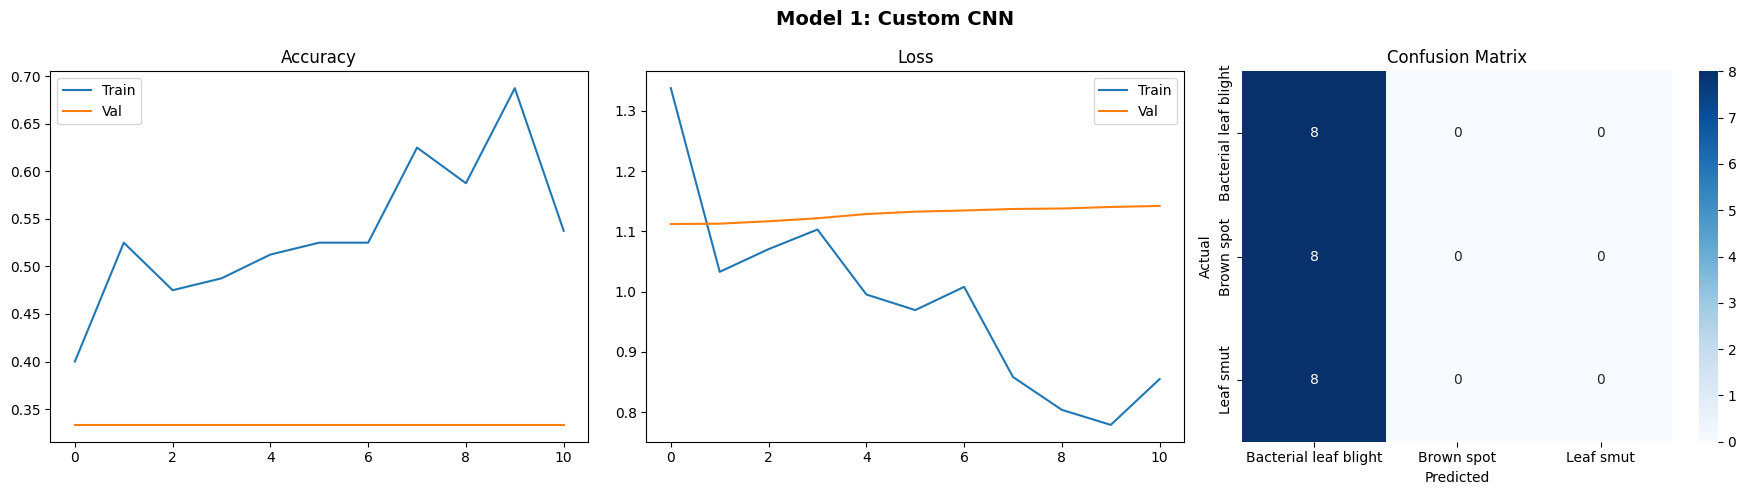

In [ ]:
model1_best=keras.models.load_model('best_custom_cnn.keras')
y_pred1=np.argmax(model1_best.predict(X_test_custom),axis=1)

acc1=accuracy_score(y_test_int,y_pred1)
pre1=precision_score(y_test_int,y_pred1,average='weighted')
rec1=recall_score(y_test_int,y_pred1,average='weighted')
f11=f1_score(y_test_int,y_pred1,average='weighted')

print(classification_report(y_test_int,y_pred1,target_names=CLASSES))

fig,axes=plt.subplots(1,3,figsize=(18,5))
fig.suptitle('Model 1: Custom CNN',fontsize=14,fontweight='bold')
axes[0].plot(hist1.history['accuracy'],label='Train')
axes[0].plot(hist1.history['val_accuracy'],label='Val')
axes[0].set_title('Accuracy')
axes[0].legend()

axes[1].plot(hist1.history['loss'],label='Train')
axes[1].plot(hist1.history['val_loss'],label='Val')
axes[1].set_title('Loss')
axes[1].legend()

sns.heatmap(confusion_matrix(y_test_int,y_pred1),annot=True,fmt='d',cmap='Blues',xticklabels=CLASSES,yticklabels=CLASSES,ax=axes[2])

axes[2].set_title('Confusion Matrix')
axes[2].set_xlabel('Predicted')
axes[2].set_ylabel('Actual')

plt.tight_layout()
plt.show()

From the confusion matrix we can see that the model struggles to classify the images. It has completely failed to predict Brown spot and Leaf smut.

## **VGG16**(Transfer Learning + Fine-Tuning)

In [ ]:
base_vgg = VGG16(weights='imagenet',include_top=False,input_shape=(128,128,3))
base_vgg.trainable=False

model2=models.Sequential([
    base_vgg,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128,activation='relu',kernel_regularizer=l2(1e-4)),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(NUM_CLASSES,activation='softmax')
],name='VGG16_Transfer')

model2.compile(optimizer=Adam(1e-4),loss='categorical_crossentropy',metrics=['accuracy'])
model2.summary()

Model: "VGG16_Transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_25     │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_50 (Dense)                │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_55          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_70 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_51 (Dense)                │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,781,251 (56.39 MB)

 Trainable params: 66,307 (259.01 KB)

 Non-trainable params: 14,714,944 (56.13 MB)

In [ ]:
hist2=model2.fit(
    vgg_train_gen,
    steps_per_epoch=steps_per_epoch,
    validation_data=vgg_val_gen,
    validation_steps=validation_steps,
    epochs=20,
    callbacks=[early_stop,reduce_lr,ckpt2],
    class_weight=class_weight_dict,
    verbose=1
)

base_vgg.trainable=True
for layer in base_vgg.layers[:-4]:
  layer.trainable=False
model2.compile(optimizer=Adam(5e-6),loss='categorical_crossentropy',metrics=['accuracy'])

hist2_ft=model2.fit(
    vgg_train_gen,
    steps_per_epoch=steps_per_epoch,
    validation_data=vgg_val_gen,
    validation_steps=validation_steps,
    epochs=15,
    callbacks=[early_stop,reduce_lr,ckpt2],
    class_weight=class_weight_dict,
    verbose=1
)

Epoch 1/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 244ms/step - accuracy: 0.3750 - loss: 1.8456 - val_accuracy: 0.2000 - val_loss: 2.6217 - learning_rate: 1.0000e-04
Epoch 2/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 121ms/step - accuracy: 0.2375 - loss: 2.0471 - val_accuracy: 0.2667 - val_loss: 2.0992 - learning_rate: 1.0000e-04
Epoch 3/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 130ms/step - accuracy: 0.4250 - loss: 1.5669 - val_accuracy: 0.2667 - val_loss: 1.7878 - learning_rate: 1.0000e-04
Epoch 4/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 111ms/step - accuracy: 0.4875 - loss: 1.4572 - val_accuracy: 0.3333 - val_loss: 1.6028 - learning_rate: 1.0000e-04
Epoch 5/20
 9/10 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.3509 - loss: 1.4567
Epoch 5: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 89ms/step - accuracy: 0.3625 - loss: 1.6882 - val_accuracy: 0.2667 - val_loss: 1.4414 - learning_rate: 1.0000e-04
Epoch 6/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 92ms/step - accuracy: 0.4125 -

Used a pretrained VGG16 (ImageNet weights), first training only the top layers, then fine-tuning the last few convolutional layers. This significantly improved results:

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 714ms/step
=== VGG16 — Test Results ===
                       precision    recall  f1-score   support

Bacterial leaf blight       0.67      0.50      0.57         8
           Brown spot       0.62      0.62      0.62         8
            Leaf smut       0.50      0.62      0.56         8

             accuracy                           0.58        24
            macro avg       0.60      0.58      0.58        24
         weighted avg       0.60      0.58      0.58        24



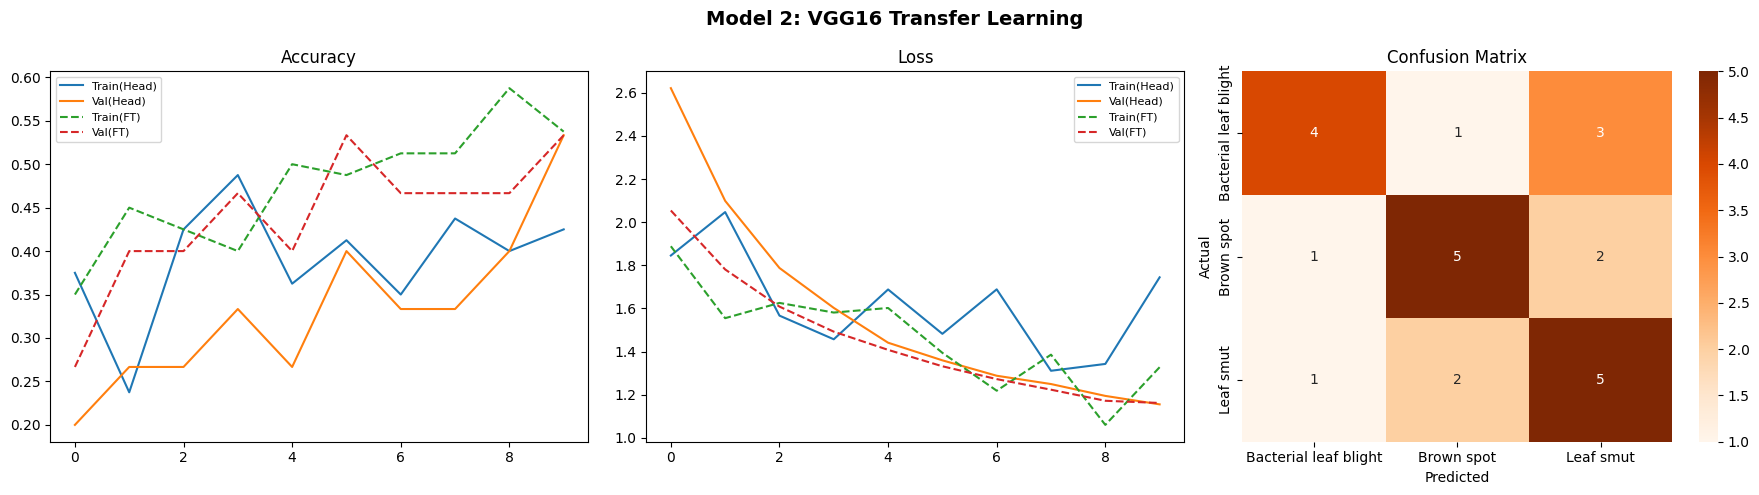

In [ ]:
model2_best = keras.models.load_model('best_vgg16.keras')
y_pred2     = np.argmax(model2_best.predict(X_test_vgg), axis=1)

acc2 = accuracy_score(y_test_int, y_pred2)
pre2 = precision_score(y_test_int,y_pred2, average='weighted')
rec2 = recall_score(y_test_int,y_pred2, average='weighted')
f12  = f1_score(y_test_int,y_pred2, average='weighted')

print('=== VGG16 — Test Results ===')
print(classification_report(y_test_int, y_pred2, target_names=CLASSES))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Model 2: VGG16 Transfer Learning', fontsize=14, fontweight='bold')
axes[0].plot(hist2.history['accuracy'],    label='Train(Head)')
axes[0].plot(hist2.history['val_accuracy'],    label='Val(Head)')
axes[0].plot(hist2_ft.history['accuracy'], label='Train(FT)', linestyle='--')
axes[0].plot(hist2_ft.history['val_accuracy'], label='Val(FT)', linestyle='--')
axes[0].set_title('Accuracy')
axes[0].legend(fontsize=8)
axes[1].plot(hist2.history['loss'],label='Train(Head)')
axes[1].plot(hist2.history['val_loss'],        label='Val(Head)')
axes[1].plot(hist2_ft.history['loss'],     label='Train(FT)', linestyle='--')
axes[1].plot(hist2_ft.history['val_loss'],     label='Val(FT)', linestyle='--')
axes[1].set_title('Loss')
axes[1].legend(fontsize=8)
sns.heatmap(confusion_matrix(y_test_int, y_pred2), annot=True, fmt='d', cmap='Oranges',
            xticklabels=CLASSES, yticklabels=CLASSES, ax=axes[2])
axes[2].set_title('Confusion Matrix')
axes[2].set_xlabel('Predicted')
axes[2].set_ylabel('Actual')
plt.tight_layout()
plt.show()

From the accuracy and loss graph we can see that the fine tuning has better results. The confusion matrix classification has shown improvement from the previous model.

## **Custom CNN** with K-Fold Cross Validation

In [ ]:
cnn_kf_accuracies = []
cnn_kf_f1_scores = []

for fold, (train_index, val_index) in enumerate(skf.split(X_kf, y_kf)):
    print(f"\n--- Fold {fold+1}/{n_splits} (Custom CNN) ---")

    X_train_fold, X_val_fold = X_kf[train_index], X_kf[val_index]
    y_train_fold, y_val_fold = y_cat[train_index], y_cat[val_index]

    fold_steps      = max(1, math.ceil(len(X_train_fold) / BATCH_SIZE))
    fold_val_steps  = max(1, math.ceil(len(X_val_fold)   / BATCH_SIZE))

    train_gen_fold = custom_train_datagen.flow(X_train_fold, y_train_fold, batch_size=BATCH_SIZE, seed=SEED)
    val_gen_fold   = custom_val_datagen.flow(X_val_fold, y_val_fold, batch_size=BATCH_SIZE, shuffle=False)

    model1_kf = Custom_CNN()
    model1_kf.compile(optimizer=Adam(5e-4), loss='categorical_crossentropy', metrics=['accuracy'])

    fold_early_stop  = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=0)
    fold_reduce_lr   = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=0)
    fold_ckpt1 = ModelCheckpoint(f'best_custom_cnn_fold_{fold+1}.keras', monitor='val_loss', save_best_only=True)

    history = model1_kf.fit(
        train_gen_fold,
        steps_per_epoch=fold_steps,
        validation_data=val_gen_fold,
        validation_steps=fold_val_steps,
        epochs=40,
        callbacks=[fold_early_stop, fold_reduce_lr, fold_ckpt1],
        class_weight=class_weight_dict,
        verbose=0
    )

    best_model_fold = keras.models.load_model(f'best_custom_cnn_fold_{fold+1}.keras')
    y_pred_fold = np.argmax(best_model_fold.predict(X_val_fold/255.0), axis=1)
    y_true_fold = np.argmax(y_val_fold, axis=1)

    f1_fold = f1_score(y_true_fold, y_pred_fold, average='weighted')
    acc_fold = accuracy_score(y_true_fold, y_pred_fold)

    cnn_kf_accuracies.append(acc_fold)
    cnn_kf_f1_scores.append(f1_fold)

    print(f"Fold {fold+1} - Accuracy: {acc_fold:.4f}, F1-Score: {f1_fold:.4f}")

print(f"\nCustom CNN K-Fold Average Accuracy: {np.mean(cnn_kf_accuracies):.4f} (+/- {np.std(cnn_kf_accuracies):.4f})")
print(f"Custom CNN K-Fold Average F1-Score: {np.mean(cnn_kf_f1_scores):.4f} (+/- {np.std(cnn_kf_f1_scores):.4f})")


--- Fold 1/5 (Custom CNN) ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 440ms/step
Fold 1 - Accuracy: 0.3333, F1-Score: 0.1667

--- Fold 2/5 (Custom CNN) ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 445ms/step
Fold 2 - Accuracy: 0.4583, F1-Score: 0.3826

--- Fold 3/5 (Custom CNN) ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 440ms/step
Fold 3 - Accuracy: 0.3333, F1-Score: 0.1667

--- Fold 4/5 (Custom CNN) ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 474ms/step
Fold 4 - Accuracy: 0.3750, F1-Score: 0.2519

--- Fold 5/5 (Custom CNN) ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 676ms/step
Fold 5 - Accuracy: 0.3913, F1-Score: 0.2910

Custom CNN K-Fold Average Accuracy: 0.3783 (+/- 0.0461)
Custom CNN K-Fold Average F1-Score: 0.2518 (+/- 0.0814)


For the Custom CNN model we perform K-Fold cross validation. It iterates through 5 folds where we split the data, initialize and train the model, and evaluate the performance.

## **VGG16** with K-Fold Cross Validation

In [ ]:
vgg16_kf_accuracies = []
vgg16_kf_f1_scores = []

for fold, (train_index, val_index) in enumerate(skf.split(X_kf, y_kf)):
    print(f"\n--- Fold {fold+1}/{n_splits} (VGG16) ---")

    X_train_fold, X_val_fold = X_kf[train_index], X_kf[val_index]
    y_train_fold, y_val_fold = y_cat[train_index], y_cat[val_index]

    fold_steps=max(1,math.ceil(len(X_train_fold)/BATCH_SIZE))
    fold_val_steps=max(1,math.ceil(len(X_val_fold)/BATCH_SIZE))

    train_gen_fold = vgg_train_datagen.flow(X_train_fold, y_train_fold, batch_size=BATCH_SIZE, seed=SEED)
    val_gen_fold   = vgg_val_datagen.flow(X_val_fold, y_val_fold, batch_size=BATCH_SIZE, shuffle=False)

    base_vgg_kf = VGG16(weights='imagenet', include_top=False, input_shape=(128,128,3))
    base_vgg_kf.trainable = False

    model2_kf = models.Sequential([
        base_vgg_kf,
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation='relu',kernel_regularizer=l2(1e-4)),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(NUM_CLASSES, activation='softmax')
    ], name=f'VGG16_Transfer_Fold{fold+1}')

    model2_kf.compile(optimizer=Adam(1e-4), loss='categorical_crossentropy', metrics=['accuracy'])

    fold_early_stop  = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=0)
    fold_reduce_lr   = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=0)
    fold_ckpt2 = ModelCheckpoint(f'best_vgg16_fold_{fold+1}.keras', monitor='val_accuracy', save_best_only=True)

    history_head = model2_kf.fit(
        train_gen_fold,
        steps_per_epoch=fold_steps,
        validation_data=val_gen_fold,
        validation_steps=fold_val_steps,
        epochs=20,
        callbacks=[fold_early_stop, fold_reduce_lr, fold_ckpt2],
        class_weight=class_weight_dict,
        verbose=0
    )

    base_vgg_kf.trainable = True
    for layer in base_vgg_kf.layers[:-8]:
        layer.trainable = False

    model2_kf.compile(optimizer=Adam(5e-6), loss='categorical_crossentropy', metrics=['accuracy'])

    history_ft = model2_kf.fit(
        train_gen_fold,
        steps_per_epoch=fold_steps,
        validation_data=val_gen_fold,
        validation_steps=fold_val_steps,
        epochs=15,
        callbacks=[fold_early_stop, fold_reduce_lr, fold_ckpt2],
        class_weight=class_weight_dict,
        verbose=0
    )

    best_model_fold = keras.models.load_model(f'best_vgg16_fold_{fold+1}.keras')
    y_pred_fold = np.argmax(best_model_fold.predict(vgg_preprocess(X_val_fold.copy())), axis=1)
    y_true_fold = np.argmax(y_val_fold, axis=1)

    f1_fold = f1_score(y_true_fold, y_pred_fold, average='weighted')
    acc_fold = accuracy_score(y_true_fold, y_pred_fold)

    vgg16_kf_accuracies.append(acc_fold)
    vgg16_kf_f1_scores.append(f1_fold)

    print(f"Fold {fold+1} - Accuracy: {acc_fold:.4f}, F1-Score: {f1_fold:.4f}")

print(f"\nVGG16 K-Fold Average Accuracy: {np.mean(vgg16_kf_accuracies):.4f} (+/- {np.std(vgg16_kf_accuracies):.4f})")
print(f"VGG16 K-Fold Average F1-Score: {np.mean(vgg16_kf_f1_scores):.4f} (+/- {np.std(vgg16_kf_f1_scores):.4f})")


--- Fold 1/5 (VGG16) ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 655ms/step
Fold 1 - Accuracy: 0.8333, F1-Score: 0.8370

--- Fold 2/5 (VGG16) ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 668ms/step
Fold 2 - Accuracy: 0.7917, F1-Score: 0.7844

--- Fold 3/5 (VGG16) ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 713ms/step
Fold 3 - Accuracy: 0.8750, F1-Score: 0.8750

--- Fold 4/5 (VGG16) ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 715ms/step
Fold 4 - Accuracy: 0.9167, F1-Score: 0.9132

--- Fold 5/5 (VGG16) ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 633ms/step
Fold 5 - Accuracy: 0.7826, F1-Score: 0.7816

VGG16 K-Fold Average Accuracy: 0.8399 (+/- 0.0506)
VGG16 K-Fold Average F1-Score: 0.8382 (+/- 0.0511)


 K-Fold Cross-Validation for the VGG16 transfer learning model. For each fold, it trains the model in two phases (head training then fine-tuning), evaluates its performance, and then aggregates the accuracy and F1-scores to provide a robust average performance estimate.

## **MobileNetV2** (Transfer Learning and Fine Tuning)

In [ ]:
base_mob = MobileNetV2(weights='imagenet', include_top=False,
                       input_shape=(128,128,3), alpha=1.0)
base_mob.trainable = False

model3 = models.Sequential([
    base_mob,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu',kernel_regularizer=l2(1e-4)),
    layers.BatchNormalization(), layers.Dropout(0.4),
    layers.Dense(NUM_CLASSES, activation='softmax')
], name='MobileNetV2_Transfer')

model3.compile(optimizer=Adam(1e-4), loss='categorical_crossentropy', metrics=['accuracy'])
model3.summary()

Model: "MobileNetV2_Transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_36     │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_72 (Dense)                │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_76          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_96 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_73 (Dense)                │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,851 (9.24 MB)

 Trainable params: 164,611 (643.01 KB)

 Non-trainable params: 2,258,240 (8.61 MB)

In [ ]:
print('Phase 1: Training MobileNetV2 head...')
hist3 = model3.fit(
  mobilenet_train_gen, steps_per_epoch=steps_per_epoch,
  validation_data=mobilenet_val_gen, validation_steps=validation_steps,
  epochs=20, callbacks=[early_stop, reduce_lr, ckpt3],
  class_weight=class_weight_dict, verbose=1
)

base_mob.trainable = True
for layer in base_mob.layers[:-20]:
    layer.trainable = False
model3.compile(optimizer=Adam(1e-5), loss='categorical_crossentropy', metrics=['accuracy'])

print('\nPhase 2: Fine-tuning last 20 MobileNetV2 layers...')
hist3_ft = model3.fit(
    mobilenet_train_gen, steps_per_epoch=steps_per_epoch,
    validation_data=mobilenet_val_gen, validation_steps=validation_steps,
    epochs=15, callbacks=[early_stop, reduce_lr, ckpt3],
    class_weight=class_weight_dict, verbose=1
)

Phase 1: Training MobileNetV2 head...
Epoch 1/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 16s 664ms/step - accuracy: 0.5000 - loss: 1.2961 - val_accuracy: 0.5000 - val_loss: 0.9716 - learning_rate: 1.0000e-04
Epoch 2/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 112ms/step - accuracy: 0.6000 - loss: 0.9653 - val_accuracy: 0.4375 - val_loss: 0.8391 - learning_rate: 1.0000e-04
Epoch 3/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 107ms/step - accuracy: 0.5500 - loss: 1.1657 - val_accuracy: 0.6875 - val_loss: 0.7179 - learning_rate: 1.0000e-04
Epoch 4/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 112ms/step - accuracy: 0.6500 - loss: 0.9805 - val_accuracy: 0.7500 - val_loss: 0.6120 - learning_rate: 1.0000e-04
Epoch 5/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 110ms/step - accuracy: 0.7000 - loss: 0.8473 - val_accuracy: 0.9375 - val_loss: 0.5242 - learning_rate: 1.0000e-04
Epoch 6/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 119ms/step - accuracy: 0.6250 - loss: 0.9891 - val_accuracy: 0.9375 - val_loss: 0.4570 - learning_rate: 1.0000e-04
Epoch 7/20
10/10 ━━━━━━━━

We have used pre-trained MobileNetV2 for training. First for Feature Extraction, the base layers are frozen and only the newly added custom classification head is trained at a higher learning rate. Then in Fine Tuning the layers are unfrozen and recompiled to train at a slower learning rate.

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
                       precision    recall  f1-score   support

Bacterial leaf blight       0.89      1.00      0.94         8
           Brown spot       0.83      0.62      0.71         8
            Leaf smut       0.78      0.88      0.82         8

             accuracy                           0.83        24
            macro avg       0.83      0.83      0.83        24
         weighted avg       0.83      0.83      0.83        24



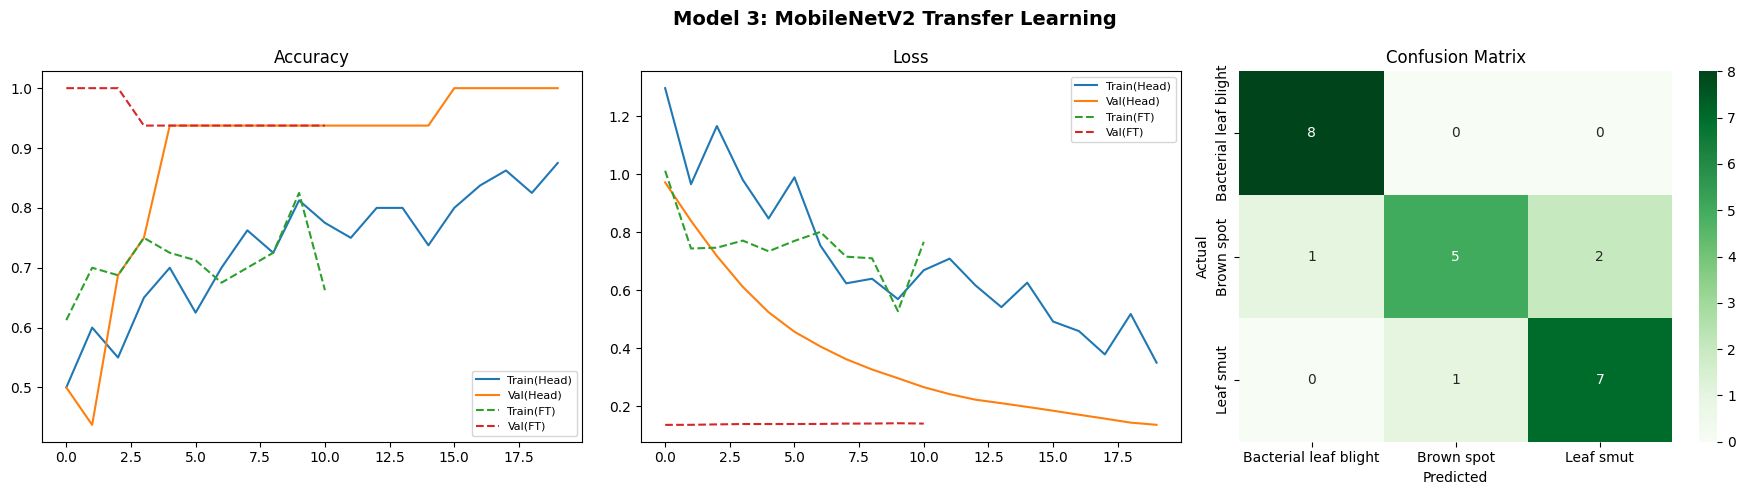

In [ ]:
model3_best=keras.models.load_model('best_mobilenet.keras')
y_pred3=np.argmax(model3_best.predict(X_test_mobilenet),axis=1)

acc3=accuracy_score(y_test_int,y_pred3)
pre3=precision_score(y_test_int,y_pred3,average='weighted')
rec3=recall_score(y_test_int,y_pred3,average='weighted')
f13=f1_score(y_test_int,y_pred3,average='weighted')

print(classification_report(y_test_int,y_pred3,target_names=CLASSES))

fig,axes=plt.subplots(1,3,figsize=(18,5))
fig.suptitle('Model 3: MobileNetV2 Transfer Learning',fontsize=14,fontweight='bold')
axes[0].plot(hist3.history['accuracy'],label='Train(Head)')
axes[0].plot(hist3.history['val_accuracy'],label='Val(Head)')
axes[0].plot(hist3_ft.history['accuracy'],label='Train(FT)',linestyle='--')
axes[0].plot(hist3_ft.history['val_accuracy'],label='Val(FT)',linestyle='--')
axes[0].set_title('Accuracy')
axes[0].legend(fontsize=8)
axes[1].plot(hist3.history['loss'],label='Train(Head)')
axes[1].plot(hist3.history['val_loss'],label="Val(Head)")
axes[1].plot(hist3_ft.history['loss'],label='Train(FT)',linestyle='--')
axes[1].plot(hist3_ft.history['val_loss'],label='Val(FT)',linestyle='--')
axes[1].set_title('Loss')
axes[1].legend(fontsize=8)
sns.heatmap(confusion_matrix(y_test_int,y_pred3),annot=True,fmt='d',cmap='Greens',xticklabels=CLASSES,yticklabels=CLASSES,ax=axes[2])
axes[2].set_title('Confusion Matrix')
axes[2].set_xlabel('Predicted')
axes[2].set_ylabel('Actual')
plt.tight_layout()
plt.show()

The training accuracy steadily increases and the loss significantly drops. Confusion matrix shows that the Bacterial blight and leaf smut are perfectly classified and the Brown spot has about 80% classification.

## **MobileNetV2** with K-Fold Cross Validation

In [ ]:
mobilenet_kf_accuracies = []
mobilenet_kf_f1_scores = []

for fold, (train_index, val_index) in enumerate(skf.split(X_kf, y_kf)):
    print(f"\n--- Fold {fold+1}/{n_splits} (MobileNetV2) ---")

    X_train_fold, X_val_fold = X_kf[train_index], X_kf[val_index]
    y_train_fold, y_val_fold = y_cat[train_index], y_cat[val_index]

    fold_steps = max(1,math.ceil(len(X_train_fold)/BATCH_SIZE))
    fold_val_steps = max(1,math.ceil(len(X_val_fold)/BATCH_SIZE))

    train_gen_fold = mobilenet_train_datagen.flow(X_train_fold, y_train_fold, batch_size=BATCH_SIZE, seed=SEED)
    val_gen_fold   = mobilenet_val_datagen.flow(X_val_fold, y_val_fold, batch_size=BATCH_SIZE, shuffle=False)

    base_mob_kf = MobileNetV2(weights='imagenet', include_top=False, input_shape=(128,128,3), alpha=1.0)
    base_mob_kf.trainable = False

    model3_kf = models.Sequential([
        base_mob_kf,
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation='relu',kernel_regularizer=l2(1e-4)),
        layers.BatchNormalization(), layers.Dropout(0.4),
        layers.Dense(NUM_CLASSES, activation='softmax')
    ], name=f'MobileNetV2_Transfer_Fold{fold+1}')

    model3_kf.compile(optimizer=Adam(1e-4), loss='categorical_crossentropy', metrics=['accuracy'])

    fold_early_stop  = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=0)
    fold_reduce_lr   = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=0)
    fold_ckpt3 = ModelCheckpoint(f'best_mobilenet_fold_{fold+1}.keras', monitor='val_loss', save_best_only=True)

    history_head = model3_kf.fit(
        train_gen_fold, steps_per_epoch=fold_steps,
        validation_data=val_gen_fold, validation_steps=fold_val_steps,
        epochs=20,
        callbacks=[fold_early_stop, fold_reduce_lr, fold_ckpt3],
        class_weight=class_weight_dict,
        verbose=0
    )

    base_mob_kf.trainable = True
    for layer in base_mob_kf.layers[:-20]:
        layer.trainable = False

    model3_kf.compile(optimizer=Adam(1e-5), loss='categorical_crossentropy', metrics=['accuracy'])

    history_ft = model3_kf.fit(
        train_gen_fold, steps_per_epoch=fold_steps,
        validation_data=val_gen_fold, validation_steps=fold_val_steps,
        epochs=15,
        callbacks=[fold_early_stop, fold_reduce_lr, fold_ckpt3],
        class_weight=class_weight_dict,
        verbose=0
    )

    best_model_fold = keras.models.load_model(f'best_mobilenet_fold_{fold+1}.keras')
    y_pred_fold = np.argmax(best_model_fold.predict(mobilenet_preprocess(X_val_fold.copy())), axis=1)
    y_true_fold = np.argmax(y_val_fold, axis=1)

    f1_fold = f1_score(y_true_fold, y_pred_fold, average='weighted')
    acc_fold = accuracy_score(y_true_fold, y_pred_fold)

    mobilenet_kf_accuracies.append(acc_fold)
    mobilenet_kf_f1_scores.append(f1_fold)

    print(f"Fold {fold+1} - Accuracy: {acc_fold:.4f}, F1-Score: {f1_fold:.4f}")

print(f"\nMobileNetV2 K-Fold Average Accuracy: {np.mean(mobilenet_kf_accuracies):.4f} (+/- {np.std(mobilenet_kf_accuracies):.4f})")
print(f"MobileNetV2 K-Fold Average F1-Score: {np.mean(mobilenet_kf_f1_scores):.4f} (+/- {np.std(mobilenet_kf_f1_scores):.4f})")


--- Fold 1/5 (MobileNetV2) ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
Fold 1 - Accuracy: 0.9167, F1-Score: 0.9165

--- Fold 2/5 (MobileNetV2) ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
Fold 2 - Accuracy: 0.8750, F1-Score: 0.8775

--- Fold 3/5 (MobileNetV2) ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
Fold 3 - Accuracy: 0.8333, F1-Score: 0.8263

--- Fold 4/5 (MobileNetV2) ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
Fold 4 - Accuracy: 0.9583, F1-Score: 0.9582

--- Fold 5/5 (MobileNetV2) ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 14s 14s/step
Fold 5 - Accuracy: 0.8261, F1-Score: 0.8190

MobileNetV2 K-Fold Average Accuracy: 0.8819 (+/- 0.0501)
MobileNetV2 K-Fold Average F1-Score: 0.8795 (+/- 0.0530)


K-Fold cross validation is performed for MobileNetV2 model. For each fold, we first train only the custom classification head, then fine-tune the last 20 layers of MobileNetV2

### Model Performance Comparison

=====Model Comparison=====
               Model  Accuracy  Precision  Recall  F1-Score
          Custom CNN    0.3333     0.1111  0.3333    0.1667
      VGG16 Transfer    0.5833     0.5972  0.5833    0.5840
MobileNetV2 Transfer    0.8333     0.8333  0.8333    0.8263


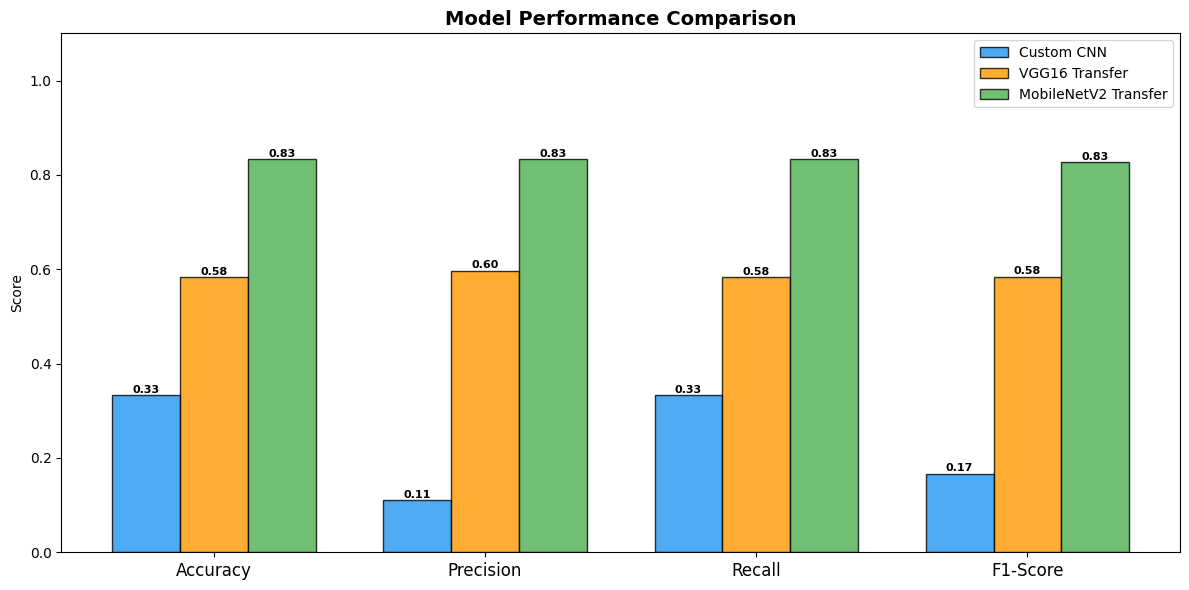


Best model by F1-Score: MobileNetV2 Transfer


In [ ]:
comparison_df=pd.DataFrame({
    'Model':['Custom CNN','VGG16 Transfer','MobileNetV2 Transfer'],
    'Accuracy':[acc1,acc2,acc3],
    'Precision':[pre1,pre2,pre3],
    'Recall':[rec1,rec2,rec3],
    'F1-Score':[f11,f12,f13],
}).round(4)

print('=====Model Comparison=====')
print(comparison_df.to_string(index=False))

metrics=['Accuracy','Precision','Recall','F1-Score']
x,w=np.arange(len(metrics)),0.25

fig,ax=plt.subplots(figsize=(12,6))
for i,(name,color) in enumerate (zip(comparison_df['Model'],['#2196F3','#FF9800','#4CAF50'])):
  vals=comparison_df[comparison_df['Model']==name][metrics].values.flatten()
  bars=ax.bar(x+i*w,vals,w,label=name,color=color,alpha=0.8,edgecolor='black')
  for b,v in zip(bars,vals):
    ax.text(b.get_x()+b.get_width()/2,b.get_height()+0.005,f'{v:.2f}',ha='center',fontsize=8,fontweight='bold')
ax.set_title('Model Performance Comparison',fontsize=14,fontweight='bold')
ax.set_xticks(x+w)
ax.set_xticklabels(metrics,fontsize=12)
ax.set_ylabel('Score')
ax.set_ylim(0,1.1)
ax.legend()
plt.tight_layout()
plt.show()

best_model=comparison_df.loc[comparison_df['F1-Score'].idxmax(),'Model']
print(f'\nBest model by F1-Score: {best_model}')

The comparison clearly shows that MobileNetV2 Transfer Learning is the most effective model, achieving the highest and most balanced Accuracy, Precision, Recall, and F1-Score among the three models.

## K-Fold Cross-Validation Results Comparison


===== K-Fold Model Comparison =====
                        Model  Average Accuracy  Std Dev Accuracy  Average F1-Score  Std Dev F1-Score
          Custom CNN (K-Fold)            0.3783            0.0461            0.2518            0.0814
      VGG16 Transfer (K-Fold)            0.8399            0.0506            0.8382            0.0511
MobileNetV2 Transfer (K-Fold)            0.8819            0.0501            0.8795            0.0530


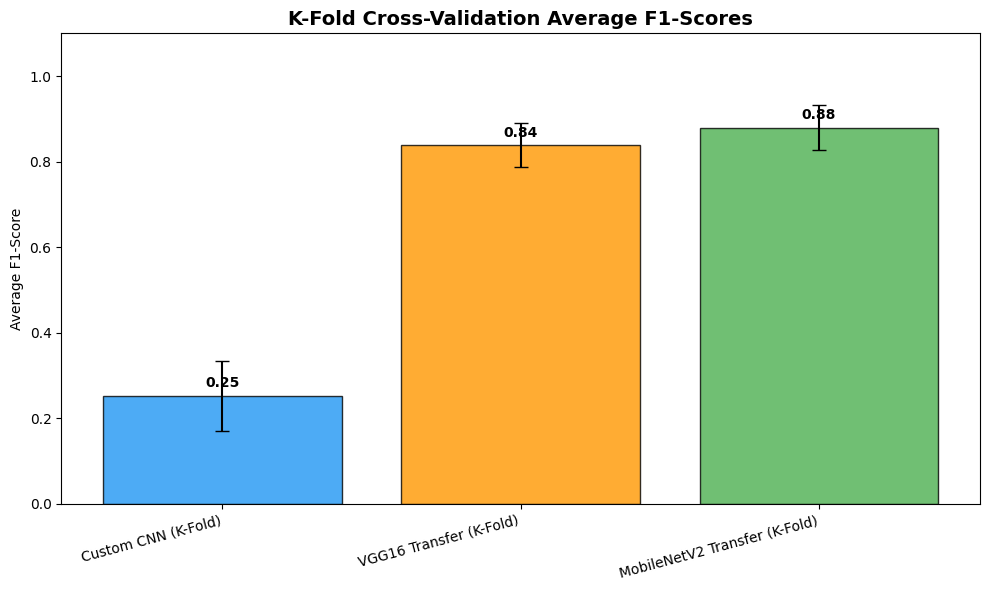


Best model by Average F1-Score (K-Fold): MobileNetV2 Transfer (K-Fold)


In [ ]:
kf_comparison_df = pd.DataFrame({
    'Model': ['Custom CNN (K-Fold)', 'VGG16 Transfer (K-Fold)', 'MobileNetV2 Transfer (K-Fold)'],
    'Average Accuracy': [np.mean(cnn_kf_accuracies), np.mean(vgg16_kf_accuracies), np.mean(mobilenet_kf_accuracies)],
    'Std Dev Accuracy': [np.std(cnn_kf_accuracies), np.std(vgg16_kf_accuracies), np.std(mobilenet_kf_accuracies)],
    'Average F1-Score': [np.mean(cnn_kf_f1_scores), np.mean(vgg16_kf_f1_scores), np.mean(mobilenet_kf_f1_scores)],
    'Std Dev F1-Score': [np.std(cnn_kf_f1_scores), np.std(vgg16_kf_f1_scores), np.std(mobilenet_kf_f1_scores)]
}).round(4)

print('\n===== K-Fold Model Comparison =====')
print(kf_comparison_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 6))
models = kf_comparison_df['Model']
avg_f1 = kf_comparison_df['Average F1-Score']
std_f1 = kf_comparison_df['Std Dev F1-Score']

bars = ax.bar(models, avg_f1, yerr=std_f1, capsize=5, color=['#2196F3', '#FF9800', '#4CAF50'], alpha=0.8, edgecolor='black')

for bar, avg_val in zip(bars, avg_f1):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02, f'{avg_val:.2f}', ha='center', fontsize=10, fontweight='bold')

ax.set_title('K-Fold Cross-Validation Average F1-Scores', fontsize=14, fontweight='bold')
ax.set_ylabel('Average F1-Score')
ax.set_ylim(0, 1.1)
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

best_kf_model = kf_comparison_df.loc[kf_comparison_df['Average F1-Score'].idxmax(), 'Model']
print(f'\nBest model by Average F1-Score (K-Fold): {best_kf_model}')

The K-Fold cross-validation results confirm that MobileNetV2 Transfer Learning is the most robust and reliable model, achieving the highest average F1-score with consistent performance across different folds.